
# Pernambuco no Comércio Exterior (2024-2026): Exportações e Importações por Município

**Objetivo**  
Construir uma análise exploratória robusta e orientada a decisão sobre o comércio exterior de Pernambuco, com foco em:
- evolução temporal,
- distribuição territorial (municípios),
- parceiros comerciais e blocos econômicos,
- composição da pauta (SH2/Seções),
- sinais de concentração e oportunidades.

> Fonte: `V_EXPORTACAO_E IMPORTACAO_POR MUNICIPIO_2024-01_2026-12_DT20260303.csv` (extração em 03/03/2026).



## 1) Setup e carregamento

Esta seção padroniza ambiente, define funções utilitárias e carrega os dados com tratamento de qualidade.


In [69]:

from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)


In [70]:

def resolve_data_path() -> Path:
    candidates = [
        Path("data/pe/comex/V_EXPORTACAO_E IMPORTACAO_POR MUNICIPIO_2024-01_2026-12_DT20260303.csv"),
        Path("../../../data/pe/comex/V_EXPORTACAO_E IMPORTACAO_POR MUNICIPIO_2024-01_2026-12_DT20260303.csv"),
        Path("../../data/pe/comex/V_EXPORTACAO_E IMPORTACAO_POR MUNICIPIO_2024-01_2026-12_DT20260303.csv"),
    ]
    for path in candidates:
        if path.exists():
            return path.resolve()
    raise FileNotFoundError("Arquivo de dados não encontrado nos caminhos esperados.")


MONTH_MAP = {
    "01": 1, "02": 2, "03": 3, "04": 4, "05": 5, "06": 6,
    "07": 7, "08": 8, "09": 9, "10": 10, "11": 11, "12": 12,
}


def clean_text(s: pd.Series) -> pd.Series:
    return (
        s.astype("string")
         .str.replace("\r", "", regex=False)
         .str.replace("\xa0", " ", regex=False)
         .str.strip()
    )


def load_comex(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=";", encoding="utf-8-sig", dtype=str)

    for col in df.columns:
        df[col] = clean_text(df[col])

    # Normalizações de tipos
    df["Ano"] = pd.to_numeric(df["Ano"], errors="coerce").astype("Int64")
    df["Valor US$ FOB"] = pd.to_numeric(df["Valor US$ FOB"], errors="coerce")
    df["Quilograma Líquido"] = pd.to_numeric(df["Quilograma Líquido"], errors="coerce")

    # Extrai número do mês de strings como '01. Janeiro'
    df["MesNum"] = df["Mês"].str.extract(r"^(\d{2})")[0].map(MONTH_MAP)
    df["Data"] = pd.to_datetime(
        dict(year=df["Ano"].astype("float"), month=df["MesNum"].astype("float"), day=1),
        errors="coerce"
    )

    # Remove linhas claramente inválidas
    df = df.dropna(subset=["Fluxo", "Ano", "MesNum", "Valor US$ FOB"])

    return df


def br_money(x: float) -> str:
    if pd.isna(x):
        return "-"
    if abs(x) >= 1e9:
        return f"US$ {x/1e9:,.2f} bi".replace(",", "X").replace(".", ",").replace("X", ".")
    if abs(x) >= 1e6:
        return f"US$ {x/1e6:,.1f} mi".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"US$ {x:,.0f}".replace(",", ".")


In [71]:

DATA_PATH = resolve_data_path()
df_raw = load_comex(DATA_PATH)

# Dado contém múltiplas classificações de bloco para a mesma transação.
# Para totais (US$ e kg), deduplicamos ignorando 'Bloco Econômico' para evitar dupla contagem.
key_cols = [c for c in df_raw.columns if c != "Bloco Econômico"]
df = df_raw.drop_duplicates(subset=key_cols).copy()

# Versão para análise de blocos: escolhe um bloco por transação, priorizando blocos específicos.
global_regions = {
    "África", "Europa", "Oceania", "América do Sul", "América do Norte",
    "Oriente Médio", "América Central e Caribe", "Ásia (Exclusive Oriente Médio)",
}

df_block = df_raw.copy()
df_block["is_global_region"] = df_block["Bloco Econômico"].isin(global_regions)
df_block = (
    df_block
    .sort_values(["is_global_region", "Bloco Econômico"], ascending=[True, True])
    .drop_duplicates(subset=key_cols, keep="first")
    .drop(columns="is_global_region")
)

print(f"Arquivo: {DATA_PATH}")
print(f"Linhas originais: {len(df_raw):,}")
print(f"Linhas após deduplicação p/ totais: {len(df):,}")
print(f"Linhas para análise de blocos (1 bloco/transação): {len(df_block):,}")


Arquivo: /Users/jwcunha/Documents/repos/phd-datascience/analise-contratos-publicos/data/pe/comex/V_EXPORTACAO_E IMPORTACAO_POR MUNICIPIO_2024-01_2026-12_DT20260303.csv
Linhas originais: 112,095
Linhas após deduplicação p/ totais: 81,413
Linhas para análise de blocos (1 bloco/transação): 81,413



## 2) Escopo da base e qualidade dos dados

Antes dos insights, validamos cobertura temporal, volumes por fluxo e integridade mínima.


In [72]:

coverage = (
    df.groupby(["Ano", "MesNum"], as_index=False)
      .agg(valor_usd=("Valor US$ FOB", "sum"), n_registros=("Fluxo", "size"))
      .sort_values(["Ano", "MesNum"])
)

flux_counts = df["Fluxo"].value_counts().rename_axis("Fluxo").reset_index(name="Registros")

missing = (
    df[["Fluxo", "Ano", "Mês", "País", "Município", "Código SH2", "Valor US$ FOB", "Quilograma Líquido"]]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("% missing")
    .to_frame()
)

start_date = df["Data"].min()
end_date = df["Data"].max()

print(f"Cobertura temporal efetiva: {start_date:%m/%Y} a {end_date:%m/%Y}")
print(f"Observacao: nome do arquivo menciona 2026-12, mas a extracao atual vai ate {end_date:%m/%Y}.")

display(flux_counts)
display(coverage.tail(12))
display(missing)


,% missing
Fluxo,0.0
Ano,0.0
Mês,0.0
País,0.0
Município,0.0
Código SH2,0.0
Valor US$ FOB,0.0
Quilograma Líquido,0.0



## 3) Painel executivo

Leitura de alto nível para decisão: tamanho do comércio, saldo e dinâmica anual/temporal.


In [73]:

kpi = (
    df.groupby("Fluxo", as_index=False)["Valor US$ FOB"].sum()
      .rename(columns={"Valor US$ FOB": "valor"})
)

exp_total = kpi.loc[kpi["Fluxo"].eq("Exportação"), "valor"].sum()
imp_total = kpi.loc[kpi["Fluxo"].eq("Importação"), "valor"].sum()
saldo_total = exp_total - imp_total

monthly = (
    df.groupby(["Data", "Fluxo"], as_index=False)["Valor US$ FOB"].sum()
      .pivot(index="Data", columns="Fluxo", values="Valor US$ FOB")
      .fillna(0)
      .rename_axis(None, axis=1)
)
if "Exportação" not in monthly.columns:
    monthly["Exportação"] = 0
if "Importação" not in monthly.columns:
    monthly["Importação"] = 0
monthly["Saldo"] = monthly["Exportação"] - monthly["Importação"]
monthly = monthly.reset_index()

annual = (
    df.groupby(["Ano", "Fluxo"], as_index=False)["Valor US$ FOB"].sum()
      .pivot(index="Ano", columns="Fluxo", values="Valor US$ FOB")
      .fillna(0)
      .rename_axis(None, axis=1)
      .reset_index()
)
if "Exportação" not in annual.columns:
    annual["Exportação"] = 0
if "Importação" not in annual.columns:
    annual["Importação"] = 0
annual["Saldo"] = annual["Exportação"] - annual["Importação"]

# YTD comparavel: usa os meses efetivamente disponiveis do ultimo ano
last_year = int(df["Ano"].max())
months_last_year = sorted(df.loc[df["Ano"].eq(last_year), "MesNum"].dropna().unique().tolist())

ytd = (
    df[df["MesNum"].isin(months_last_year)]
      .groupby(["Ano", "Fluxo"], as_index=False)["Valor US$ FOB"].sum()
      .pivot(index="Ano", columns="Fluxo", values="Valor US$ FOB")
      .fillna(0)
      .rename_axis(None, axis=1)
      .reset_index()
)
if "Exportação" not in ytd.columns:
    ytd["Exportação"] = 0
if "Importação" not in ytd.columns:
    ytd["Importação"] = 0
ytd["Saldo"] = ytd["Exportação"] - ytd["Importação"]

kpi_summary = pd.DataFrame({
    "Indicador": [
        "Exportacoes acumuladas",
        "Importacoes acumuladas",
        "Saldo comercial acumulado",
        "Meses no recorte YTD comparavel",
    ],
    "Valor": [
        br_money(exp_total),
        br_money(imp_total),
        br_money(saldo_total),
        ", ".join(map(str, months_last_year)),
    ]
})

display(kpi_summary)
display(annual)
display(ytd)


,Ano,Exportação,Importação,Saldo
0,2024,153726357,607251554,-453525197
1,2025,174880095,760927322,-586047227
2,2026,129403833,598793188,-469389355


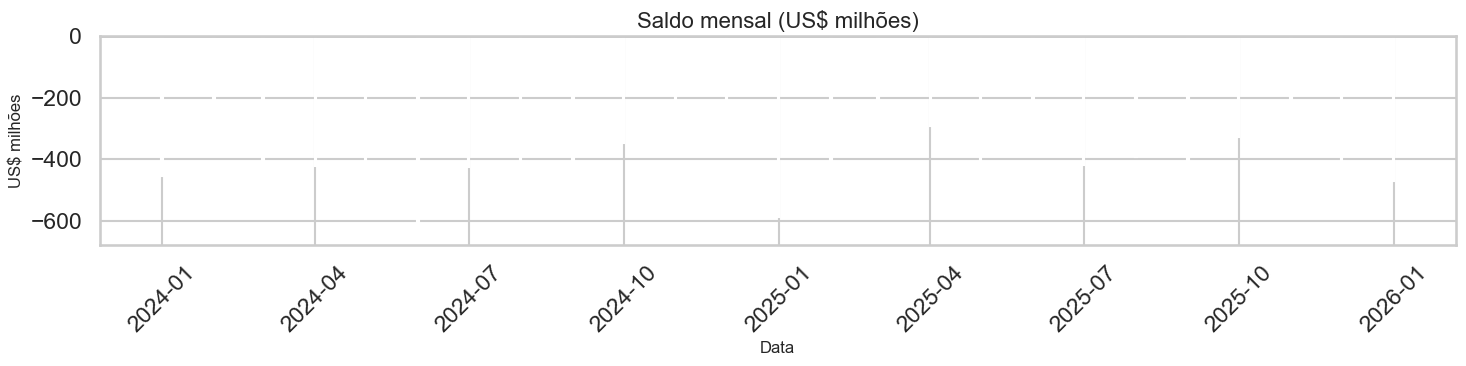

In [74]:

fig, ax = plt.subplots(1, 1, figsize=(15, 6))
ax.plot(monthly["Data"], monthly["Exportação"] / 1e6, marker="o", linewidth=2, label="Exportação")
ax.plot(monthly["Data"], monthly["Importação"] / 1e6, marker="o", linewidth=2, label="Importação")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Evolução mensal: Exportações vs Importações (US$ milhões)")
ax.set_ylabel("US$ milhões")
ax.set_xlabel("Data")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(15, 4))
colors = np.where(monthly["Saldo"] >= 0, "#1b9e77", "#d95f02")
ax.bar(monthly["Data"], monthly["Saldo"] / 1e6, color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Saldo mensal (US$ milhões)")
ax.set_ylabel("US$ milhões")
ax.set_xlabel("Data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 4) Geografia econômica: municípios protagonistas

Aqui identificamos onde o comércio exterior está concentrado no estado e quais municípios sustentam a pauta.


In [75]:

def top_municipios(fluxo: str, top_n: int = 12) -> pd.DataFrame:
    x = (
        df[df["Fluxo"].eq(fluxo)]
        .groupby("Município", as_index=False)
        .agg(
            valor_usd=("Valor US$ FOB", "sum"),
            kg=("Quilograma Líquido", "sum"),
            paises=("País", "nunique"),
            produtos_sh2=("Código SH2", "nunique"),
        )
        .sort_values("valor_usd", ascending=False)
        .head(top_n)
    )
    x["usd_kg"] = np.where(x["kg"] > 0, x["valor_usd"] / x["kg"], np.nan)
    return x

exp_mun = top_municipios("Exportação")
imp_mun = top_municipios("Importação")

print("Top municipios exportadores")
display(exp_mun)
print("Top municipios importadores")
display(imp_mun)


,Município,valor_usd,kg,paises,produtos_sh2,usd_kg
31,Ipojuca - PE,5155380178,8749001327,55,52,0.589254
25,Goiana - PE,3244851114,340558939,53,35,9.528016
13,Cabo de Santo Agostinho - PE,2146876311,1346448568,65,69,1.594473
52,Recife - PE,2042520609,1819531703,89,88,1.122553
34,Jaboatão dos Guararapes - PE,862172135,530120101,78,75,1.626371
6,Belo Jardim - PE,320107577,112230201,53,37,2.852241
33,Itapissuma - PE,229363379,363935090,32,16,0.630232
17,Caruaru - PE,213442813,108407212,38,68,1.968899
29,Igarassu - PE,152718175,167743279,30,37,0.910428
41,Olinda - PE,130242437,305612920,20,33,0.426168


In [76]:

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=False)

sns.barplot(data=exp_mun.sort_values("valor_usd"), y="Município", x="valor_usd", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Exportações: Top municípios")
axes[0].set_xlabel("US$ FOB")
axes[0].set_ylabel("")

sns.barplot(data=imp_mun.sort_values("valor_usd"), y="Município", x="valor_usd", ax=axes[1], color="#e76f51")
axes[1].set_title("Importações: Top municípios")
axes[1].set_xlabel("US$ FOB")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Concentração por município
for fluxo in ["Exportação", "Importação"]:
    base = (
        df[df["Fluxo"].eq(fluxo)]
        .groupby("Município", as_index=False)["Valor US$ FOB"].sum()
        .sort_values("Valor US$ FOB", ascending=False)
    )
    base["share"] = base["Valor US$ FOB"] / base["Valor US$ FOB"].sum()
    hhi = (base["share"] ** 2).sum()
    top5_share = base["share"].head(5).sum()
    print(f"{fluxo}: HHI municipal={hhi:.3f} | participacao Top-5={top5_share:.1%}")


Exportação: HHI municipal=0.194 | participacao Top-5=74.0%
Importação: HHI municipal=0.203 | participacao Top-5=88.5%



## 5) Parceiros internacionais e blocos econômicos

Leitura em duas camadas:
- **Países** (transação deduplicada);
- **Blocos** (um bloco representativo por transação para evitar duplicidade analítica).


In [77]:

def top_parceiros(fluxo: str, top_n: int = 15) -> pd.DataFrame:
    out = (
        df[df["Fluxo"].eq(fluxo)]
        .groupby("País", as_index=False)
        .agg(valor_usd=("Valor US$ FOB", "sum"), kg=("Quilograma Líquido", "sum"))
        .sort_values("valor_usd", ascending=False)
        .head(top_n)
    )
    out["usd_kg"] = np.where(out["kg"] > 0, out["valor_usd"] / out["kg"], np.nan)
    out["share"] = out["valor_usd"] / out["valor_usd"].sum()
    return out

exp_country = top_parceiros("Exportação", top_n=12)
imp_country = top_parceiros("Importação", top_n=12)

print("Top destinos das exportacoes")
display(exp_country)
print("Top origens das importacoes")
display(imp_country)

block_mix = (
    df_block.groupby(["Fluxo", "Bloco Econômico"], as_index=False)["Valor US$ FOB"].sum()
    .sort_values(["Fluxo", "Valor US$ FOB"], ascending=[True, False])
)
block_mix["share_fluxo"] = block_mix["Valor US$ FOB"] / block_mix.groupby("Fluxo")["Valor US$ FOB"].transform("sum")

print("Mix por bloco economico (um bloco por transacao)")
display(block_mix.head(20))


,Fluxo,Bloco Econômico,Valor US$ FOB,share_fluxo
6,Exportação,Mercado Comum do Sul - Mercosul,1728207021,0.373342
1,Exportação,América do Norte,774926742,0.167406
10,Exportação,África,558883709,0.120735
9,Exportação,União Europeia - UE,487108700,0.10523
2,Exportação,América do Sul,215709863,0.0466
3,Exportação,Associação de Nações do Sudeste Asiático - ASEAN,214524100,0.046343
11,Exportação,Ásia (Exclusive Oriente Médio),212118245,0.045824
4,Exportação,Comunidade Andina das Nações - CAN,182823616,0.039495
5,Exportação,Europa,110003335,0.023764
0,Exportação,América Central e Caribe,86895114,0.018772


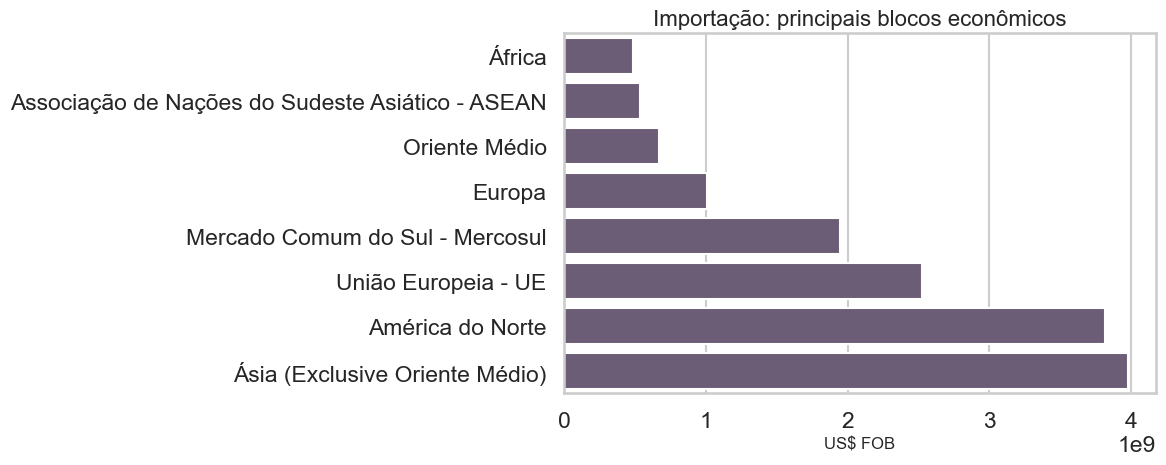

In [78]:

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=exp_country.sort_values("valor_usd"), y="País", x="valor_usd", ax=axes[0], color="#457b9d")
axes[0].set_title("Exportações: principais destinos")
axes[0].set_xlabel("US$ FOB")
axes[0].set_ylabel("")

sns.barplot(data=imp_country.sort_values("valor_usd"), y="País", x="valor_usd", ax=axes[1], color="#f4a261")
axes[1].set_title("Importações: principais origens")
axes[1].set_xlabel("US$ FOB")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

for fluxo in ["Exportação", "Importação"]:
    temp = block_mix[block_mix["Fluxo"].eq(fluxo)].head(8)
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=temp.sort_values("Valor US$ FOB"), y="Bloco Econômico", x="Valor US$ FOB", ax=ax, color="#6d597a")
    ax.set_title(f"{fluxo}: principais blocos econômicos")
    ax.set_xlabel("US$ FOB")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()



## 6) Estrutura da pauta: produtos (SH2) e seções

Nesta etapa, avaliamos o que Pernambuco vende e compra no exterior, e o nível de concentração da pauta.


In [79]:

def top_produtos_sh2(fluxo: str, top_n: int = 15) -> pd.DataFrame:
    out = (
        df[df["Fluxo"].eq(fluxo)]
        .groupby(["Código SH2", "Descrição SH2"], as_index=False)
        .agg(valor_usd=("Valor US$ FOB", "sum"), kg=("Quilograma Líquido", "sum"))
        .sort_values("valor_usd", ascending=False)
        .head(top_n)
    )
    out["usd_kg"] = np.where(out["kg"] > 0, out["valor_usd"] / out["kg"], np.nan)
    out["share"] = out["valor_usd"] / out["valor_usd"].sum()
    return out

exp_sh2 = top_produtos_sh2("Exportação")
imp_sh2 = top_produtos_sh2("Importação")

print("Top SH2 - Exportacao")
display(exp_sh2)
print("Top SH2 - Importacao")
display(imp_sh2)

section_mix = (
    df.groupby(["Fluxo", "Código Seção", "Descrição Seção"], as_index=False)["Valor US$ FOB"].sum()
    .sort_values(["Fluxo", "Valor US$ FOB"], ascending=[True, False])
)
section_mix["share_fluxo"] = section_mix["Valor US$ FOB"] / section_mix.groupby("Fluxo")["Valor US$ FOB"].transform("sum")

print("Mix por secao NCM")
display(section_mix.head(20))


,Fluxo,Código Seção,Descrição Seção,Valor US$ FOB,share_fluxo
17,Exportação,XVII,Material de transporte,1786862648,0.386014
3,Exportação,IV,"Produtos das indútrias alimentares; Bebidas, l...",809639389,0.174905
1,Exportação,II,Produtos do reino vegetal,587520309,0.126921
5,Exportação,V,Produtos minerais,554793556,0.119851
7,Exportação,VII,Plásticos e suas obras; Borracha e suas obras,252806699,0.054614
15,Exportação,XV,Metais comuns e suas obras,237264969,0.051256
16,Exportação,XVI,"Máquinas e aparelhos, material elétrico e suas...",225971945,0.048816
0,Exportação,I,Animais vivos e produtos do reino animal,83016788,0.017934
6,Exportação,VI,Produtos das indústrias químicas ou indústrias...,34835927,0.007526
12,Exportação,XIII,"Obras de pedra, gesso, cimento, amianto, mica ...",15354698,0.003317


In [80]:

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(data=exp_sh2.sort_values("valor_usd"), y="Código SH2", x="valor_usd", ax=axes[0], color="#264653")
axes[0].set_title("Exportações: Top SH2 por valor")
axes[0].set_xlabel("US$ FOB")
axes[0].set_ylabel("Código SH2")

sns.barplot(data=imp_sh2.sort_values("valor_usd"), y="Código SH2", x="valor_usd", ax=axes[1], color="#e9c46a")
axes[1].set_title("Importações: Top SH2 por valor")
axes[1].set_xlabel("US$ FOB")
axes[1].set_ylabel("Código SH2")

plt.tight_layout()
plt.show()

# Concentração da pauta (HHI por SH2)
for fluxo in ["Exportação", "Importação"]:
    temp = (
        df[df["Fluxo"].eq(fluxo)]
        .groupby("Código SH2", as_index=False)["Valor US$ FOB"].sum()
        .sort_values("Valor US$ FOB", ascending=False)
    )
    temp["share"] = temp["Valor US$ FOB"] / temp["Valor US$ FOB"].sum()
    hhi = (temp["share"] ** 2).sum()
    top3 = temp["share"].head(3).sum()
    print(f"{fluxo}: HHI da pauta SH2={hhi:.3f} | participacao Top-3 SH2={top3:.1%}")


Exportação: HHI da pauta SH2=0.208 | participacao Top-3 SH2=66.8%
Importação: HHI da pauta SH2=0.128 | participacao Top-3 SH2=53.0%



## 7) Storytelling analítico: sinais de performance, risco e oportunidade

A leitura abaixo traduz os dados em uma narrativa executiva acionável.


### Leitura guiada dos insights
A celula seguinte gera automaticamente uma sintese executiva com base nos resultados calculados acima.

In [83]:
# Tendencia recente (ultimos 6 meses disponiveis)
last_months = monthly.sort_values("Data").tail(6).copy()
last_months["saldo_pos"] = np.where(last_months["Saldo"] >= 0, "superavit", "deficit")

# Maior municipio exportador/importador
top_exp_mun = exp_mun.iloc[0]
top_imp_mun = imp_mun.iloc[0]

# Parceiros lideres
top_exp_country = exp_country.iloc[0]
top_imp_country = imp_country.iloc[0]

# Produtos lideres
top_exp_prod = exp_sh2.iloc[0]
top_imp_prod = imp_sh2.iloc[0]

# Variacao YoY do YTD comparavel (ultimo ano vs ano anterior)
ytd_sorted = ytd.sort_values("Ano")
yoy_note = "Sem base suficiente para variacao YoY no recorte comparavel."
if len(ytd_sorted) >= 2:
    prev = ytd_sorted.iloc[-2]
    curr = ytd_sorted.iloc[-1]
    exp_growth = (curr["Exportação"] / prev["Exportação"] - 1) if prev["Exportação"] > 0 else np.nan
    imp_growth = (curr["Importação"] / prev["Importação"] - 1) if prev["Importação"] > 0 else np.nan
    yoy_note = (
        f"No recorte comparavel de {len(months_last_year)} mes(es) em {int(curr['Ano'])} vs {int(prev['Ano'])}: "
        f"exportacoes {exp_growth:+.1%} e importacoes {imp_growth:+.1%}."
    )

superavit_count = int((last_months["Saldo"] >= 0).sum())
deficit_count = len(last_months) - superavit_count
if superavit_count >= deficit_count:
    pulso_label = "superavit"
    pulso_count = superavit_count
else:
    pulso_label = "deficit"
    pulso_count = deficit_count

# Escape para markdown (especialmente o simbolo $)
def md_safe(s: str) -> str:
    return str(s).replace("$", "\\$")

mov_total = md_safe(br_money(exp_total + imp_total))
saldo_fmt = md_safe(br_money(saldo_total))
exp_mun_val = md_safe(br_money(top_exp_mun['valor_usd']))
imp_mun_val = md_safe(br_money(top_imp_mun['valor_usd']))
exp_country_val = md_safe(br_money(top_exp_country['valor_usd']))
imp_country_val = md_safe(br_money(top_imp_country['valor_usd']))
exp_sh2_val = md_safe(br_money(top_exp_prod['valor_usd']))
imp_sh2_val = md_safe(br_money(top_imp_prod['valor_usd']))
yoy_note = md_safe(yoy_note)

resumo_md = f"""
### Narrativa executiva
- **Escala e balanco:** Pernambuco movimenta **{mov_total}** no periodo, com saldo acumulado de **{saldo_fmt}**.
- **Motor territorial:** {top_exp_mun['Município']} lidera exportacoes ({exp_mun_val}); {top_imp_mun['Município']} lidera importacoes ({imp_mun_val}).
- **Integracao internacional:** principal destino exportador: **{top_exp_country['País']}** ({exp_country_val}); principal origem importadora: **{top_imp_country['País']}** ({imp_country_val}).
- **Vocacao da pauta:** SH2 lider em exportacao: **{top_exp_prod['Código SH2']}** ({exp_sh2_val}); em importacao: **{top_imp_prod['Código SH2']}** ({imp_sh2_val}).
- **Pulso recente:** nos ultimos 6 meses disponiveis, prevalece **{pulso_label}** em **{pulso_count} de {len(last_months)}** meses.
- **Comparavel YTD:** {yoy_note}

### Sinais estrategicos
1. Concentracao elevada em municipios/produtos aumenta vulnerabilidade a choques setoriais.
2. Blocos e mercados intermediarios podem ser alvos de diversificacao comercial.
3. US$/kg combinado ao FOB ajuda a identificar produtos de maior valor agregado.
"""

display(Markdown(resumo_md))



### Narrativa executiva
- **Escala e balanco:** Pernambuco movimenta **US\$ 19,83 bi** no periodo, com saldo acumulado de **US\$ -10,57 bi**.
- **Motor territorial:** Goiana - PE lidera exportacoes (US\$ 1,77 bi); Ipojuca - PE lidera importacoes (US\$ 5,16 bi).
- **Integracao internacional:** principal destino exportador: **Argentina** (US\$ 1,55 bi); principal origem importadora: **Estados Unidos** (US\$ 3,01 bi).
- **Vocacao da pauta:** SH2 lider em exportacao: **87** (US\$ 1,77 bi); em importacao: **27** (US\$ 4,10 bi).
- **Pulso recente:** nos ultimos 6 meses disponiveis, prevalece **deficit** em **6 de 6** meses.
- **Comparavel YTD:** No recorte comparavel de 1 mes(es) em 2026 vs 2025: exportacoes -26.0% e importacoes -21.3%.

### Sinais estrategicos
1. Concentracao elevada em municipios/produtos aumenta vulnerabilidade a choques setoriais.
2. Blocos e mercados intermediarios podem ser alvos de diversificacao comercial.
3. US$/kg combinado ao FOB ajuda a identificar produtos de maior valor agregado.



## 8) Próximos aprofundamentos recomendados

1. Abrir a análise por **intensidade tecnológica** e **complexidade produtiva** (crosswalk SH2/OCDE).  
2. Construir **monitor mensal automatizado** de saldo, concentração e alertas por município/produto.  
3. Integrar câmbio/frete internacional para decompor variações de valor em **preço vs volume**.  
4. Criar trilha de oportunidades por município com matriz: `participação atual x potencial de expansão`.
